# Análisis PISA 2025 — México

Notebook para generar 6 gráficas a partir de los microdatos oficiales de la OCDE,
**con márgenes de error calculados correctamente**.

## Antes de empezar

**1. Instala las librerías** (una sola vez, en la terminal de VSCode):

```bash
pip install pandas numpy matplotlib pyreadstat
```

**2. Descarga el archivo correcto.** En
https://www.oecd.org/en/data/datasets/pisa-2025-database.html,
pestaña **PISA 2025**, sección SPSS, el que dice
**"Student questionnaire data file"**.

> ⚠️ Ojo con esto: el de *School questionnaire* tiene una fila por escuela y no
> contiene puntajes ni pesos de estudiante. El de *PISA for Development* es otro
> programa distinto donde México ni siquiera participa. El que necesitas es el de
> **Student questionnaire**, y pesa varios GB.

**3. Estructura de carpetas:**

```
mi-proyecto-pisa/
├── analisis_pisa.ipynb
├── datos/
│   └── (aquí el .sav de estudiantes)
└── figuras/            <- se crea sola
```

Si dejas varios `.sav` en la carpeta no pasa nada: el notebook detecta solo el de
estudiantes revisando las columnas de cada uno.

**4. En VSCode:** selecciona el kernel de Python arriba a la derecha y corre las celdas
en orden con `Shift + Enter`.

---

## Qué hace cada gráfica

| # | Gráfica | ¿Necesita el `.sav`? |
|---|---------|----------------------|
| 1 | Evolución de México 2003–2025 | No |
| 2 | México vs promedio OCDE 2025 | No |
| 3 | ¿Cuántos no saben lo básico? | Sí |
| 4 | ¿Importa ser rico o pobre? | Sí |
| 5 | ¿Niñas y niños rinden igual? | Sí |
| 6 | ¿Los que usan IA sacan mejores notas? | Sí |


---
# 0. Configuración

Lo único que quizá tengas que cambiar.

In [30]:
from pathlib import Path

CARPETA_DATOS   = Path("datos")
CARPETA_FIGURAS = Path("figuras")

PAIS = "MEX"
PAIS_NOMBRE = "México"

# Otros países que quieres tener cargados para comparar
COMPARAR_CON = ["CHL", "URY", "BRA", "COL"]

CARPETA_FIGURAS.mkdir(exist_ok=True)
print("Buscaré los datos en:", CARPETA_DATOS.resolve())

Buscaré los datos en: /Users/rbkespinosa/Downloads/mi-proyecto-pisa/datos


In [31]:
import sys
print(sys.executable)

/Users/rbkespinosa/.pyenv/versions/3.12.13/bin/python


In [32]:
%pip install numpy pandas matplotlib pyreadstat


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "-",
})

VERDE, GRIS, AZUL   = "#0F7B6C", "#9AA0A6", "#3B6EA5"
NARANJA, ROJO, ROSA = "#D9822B", "#C1443C", "#C25E8B"

def guardar(fig, nombre):
    ruta = CARPETA_FIGURAS / f"{nombre}.png"
    fig.savefig(ruta)
    print(f"Guardada: {ruta}")

print("Librerías cargadas.")

Librerías cargadas.


---
# Gráfica 1 — Puntaje de México por año (2003–2025)

**Qué muestra:** cómo se ha movido México en las tres materias a lo largo de 22 años.

**De dónde salen los datos:** son los promedios nacionales **ya publicados** por la
OCDE en cada edición. No hace falta el `.sav`.

> ⚠️ En 2015 la OCDE cambió la aplicación de la prueba (de papel a computadora). Las
> comparaciones con años anteriores hay que tomarlas con reserva; lo marco con una
> línea punteada.

In [34]:
anios = [2003, 2006, 2009, 2012, 2015, 2018, 2022, 2025]

mexico_historico = pd.DataFrame({
    "anio":        anios,
    "Matemáticas": [385, 406, 419, 413, 408, 409, 395, 388],
    "Lectura":     [400, 410, 425, 424, 423, 420, 415, 408],
    "Ciencias":    [405, 410, 416, 415, 416, 419, 410, 414],
}).set_index("anio")

mexico_historico

,Matemáticas,Lectura,Ciencias
anio,,,
2003,385,400,405
2006,406,410,410
2009,419,425,416
2012,413,424,415
2015,408,423,416
2018,409,420,419
2022,395,415,410
2025,388,408,414


Guardada: figuras/01_mexico_historico.png


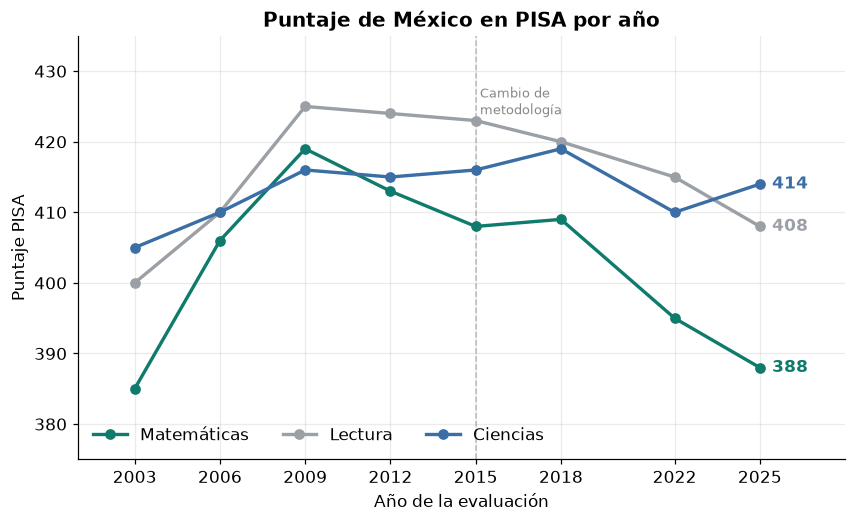

In [35]:
fig, ax = plt.subplots(figsize=(9, 5))

for materia, color in {"Matemáticas": VERDE, "Lectura": GRIS, "Ciencias": AZUL}.items():
    ax.plot(mexico_historico.index, mexico_historico[materia],
            marker="o", linewidth=2.2, markersize=6, color=color, label=materia)
    ax.annotate(f"{mexico_historico[materia].iloc[-1]}",
                xy=(anios[-1], mexico_historico[materia].iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                color=color, fontweight="bold", va="center")

ax.axvline(2015, color="#BBBBBB", linestyle="--", linewidth=1, zorder=0)
ax.text(2015.15, 428, "Cambio de\nmetodología", fontsize=8.5, color="#888888", va="top")

ax.set_title(f"Puntaje de {PAIS_NOMBRE} en PISA por año")
ax.set_xlabel("Año de la evaluación")
ax.set_ylabel("Puntaje PISA")
ax.set_xticks(anios)
ax.set_ylim(375, 435)
ax.set_xlim(2001, 2028)
ax.legend(frameon=False, loc="lower left", ncol=3)

guardar(fig, "01_mexico_historico")
plt.show()

**Cómo leerla:** las tres suben hasta 2009–2012 y de ahí van cayendo. En 2025
matemáticas (388) y lectura (408) son las más bajas en 20 años. Ciencias (414) subió
un poco respecto a 2022 pero sigue igual que hace dos décadas.

*(Nombre técnico: **serie de tiempo**)*

---
# Gráfica 2 — México vs promedio OCDE (2025)

El "promedio OCDE" es el promedio de los ~38 países miembros, donde cada país cuenta
igual sin importar su población.

In [36]:
comparacion = pd.DataFrame({
    "materia":       ["Matemáticas", "Lectura", "Ciencias"],
    "México":        [388, 408, 414],
    "Promedio OCDE": [463, 461, 482],
})
comparacion["Brecha"] = comparacion["México"] - comparacion["Promedio OCDE"]
comparacion

,materia,México,Promedio OCDE,Brecha
0,Matemáticas,388,463,-75
1,Lectura,408,461,-53
2,Ciencias,414,482,-68


Guardada: figuras/02_mexico_vs_ocde.png


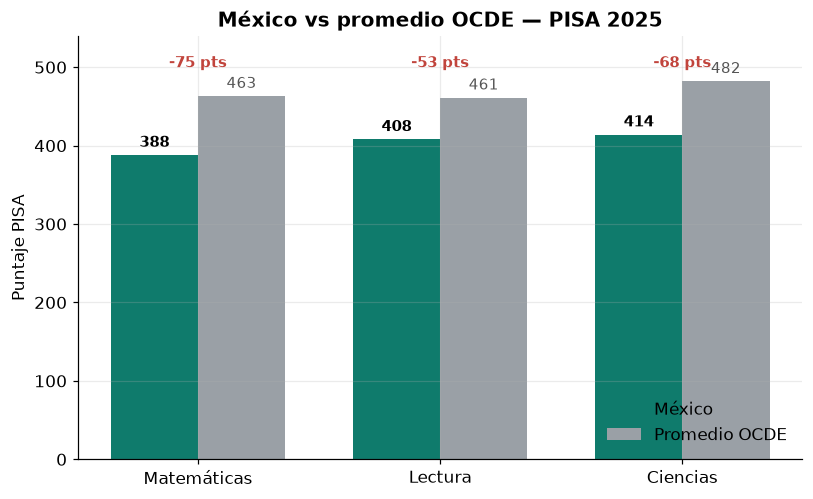

In [37]:
fig, ax = plt.subplots(figsize=(8.5, 5))

x, ancho = np.arange(len(comparacion)), 0.36
b1 = ax.bar(x - ancho/2, comparacion["México"], ancho, label=PAIS_NOMBRE, color=VERDE)
b2 = ax.bar(x + ancho/2, comparacion["Promedio OCDE"], ancho,
            label="Promedio OCDE", color=GRIS)
ax.bar_label(b1, fmt="%d", padding=3, fontweight="bold", fontsize=10)
ax.bar_label(b2, fmt="%d", padding=3, fontsize=10, color="#555555")

for i, brecha in enumerate(comparacion["Brecha"]):
    ax.annotate(f"{brecha:+d} pts", xy=(i, 500), ha="center",
                fontsize=10, color=ROJO, fontweight="bold")

ax.set_title(f"{PAIS_NOMBRE} vs promedio OCDE — PISA 2025")
ax.set_ylabel("Puntaje PISA")
ax.set_xticks(x, comparacion["materia"])
ax.set_ylim(0, 540)
ax.legend(frameon=False, loc="lower right")

guardar(fig, "02_mexico_vs_ocde")
plt.show()

**Cómo leerla:** la brecha va de 53 a 75 puntos. La OCDE estima que **20 puntos ≈
un año de aprendizaje**, así que México va entre 2.5 y 3.5 años escolares atrás.

---
# Cargando los microdatos

De aquí en adelante sí necesitamos el `.sav`.

**¿Qué son los microdatos?** Hasta ahora usamos promedios ya calculados. Ahora vamos a
la tabla original: **una fila por estudiante** y cientos de columnas con sus respuestas.

## Tres conceptos antes de empezar

### 1. No existe "el puntaje" de un estudiante

Cada alumno solo contestó una parte de la prueba. La OCDE no reporta un puntaje sino
**10 estimaciones plausibles** de cuál sería si hubiera contestado todo: `PV1SCIE`,
`PV2SCIE`, ... `PV10SCIE`.

Regla: **calculas tu resultado 10 veces (una con cada estimación) y promedias los 10
resultados.** No se promedian las 10 columnas primero.

*(Nombre técnico: **valores plausibles** / plausible values)*

### 2. No todos los estudiantes "valen" lo mismo

PISA evalúa una muestra, y no es proporcional: algunas escuelas están
sobre-representadas a propósito. Cada estudiante trae un **peso** en `W_FSTUWT` que
dice a cuántos jóvenes representa. Hay que usar promedio ponderado.

*(Nombre técnico: **pesos muestrales** / survey weights)*

### 3. Como es una muestra, cada número trae incertidumbre

Si PISA hubiera evaluado a otros 30 mil estudiantes mexicanos, el promedio habría
salido un poco distinto. Necesitamos saber **cuánto** distinto, y para eso están las
**80 columnas de pesos replicados** (`W_FSTURWT1` a `W_FSTURWT80`).

Lo explico bien más abajo, cuando las usemos.

In [38]:
import pyreadstat

# Buscar el archivo de estudiantes: es el que tiene columnas PV*SCIE
candidatos = sorted(CARPETA_DATOS.glob("*.sav"))

if not candidatos:
    raise FileNotFoundError(
        f"No hay ningún .sav en '{CARPETA_DATOS.resolve()}'.\n"
        "Descarga 'Student questionnaire data file' (SPSS) desde\n"
        "https://www.oecd.org/en/data/datasets/pisa-2025-database.html"
    )

ruta_stu, meta = None, None
print("Archivos .sav encontrados:\n")

for p in candidatos:
    _, m = pyreadstat.read_sav(p, metadataonly=True)
    cols = {c.upper() for c in m.column_names}
    es_estudiante = ("PV1SCIE" in cols) and ("W_FSTUWT" in cols)
    etiqueta = "ESTUDIANTES ✓" if es_estudiante else "otro (no sirve)"
    print(f"  {p.name}")
    print(f"     {m.number_rows:>9,} filas | {len(m.column_names):>4} columnas | "
          f"{p.stat().st_size/1e6:>8.1f} MB | {etiqueta}")
    if es_estudiante and ruta_stu is None:
        ruta_stu, meta = p, m

if ruta_stu is None:
    raise FileNotFoundError(
        "\nNinguno de esos archivos es el de estudiantes.\n"
        "El correcto debe tener las columnas PV1SCIE y W_FSTUWT.\n"
        "Descarga 'Student questionnaire data file' (SPSS): NO el de School "
        "y NO el de PISA for Development."
    )

print(f"\nUsaré: {ruta_stu.name}")
columnas_disponibles = {c.upper(): c for c in meta.column_names}

Archivos .sav encontrados:

  CY09_MS_STU_PUF.sav
       755,721 filas |  885 columnas |   2168.7 MB | ESTUDIANTES ✓

Usaré: CY09_MS_STU_PUF.sav


In [39]:
# Qué columnas queremos

COLUMNAS_QUE_QUIERO = [
    "CNT",          # país
    "CNTSCHID",     # id de escuela
    "W_FSTUWT",     # peso final del estudiante
    "ESCS",         # índice de nivel socioeconómico y cultural
    "ST004D01T",    # sexo (1 = niña, 2 = niño)
]

for dominio in ["SCIE", "MATH", "READ"]:                         # valores plausibles
    COLUMNAS_QUE_QUIERO += [f"PV{i}{dominio}" for i in range(1, 11)]

COLUMNAS_QUE_QUIERO += [f"W_FSTURWT{i}" for i in range(1, 81)]   # pesos replicados
COLUMNAS_QUE_QUIERO += [f"ST438Q0{i}DA" for i in range(1, 5)]    # uso de IA

columnas_finales = [columnas_disponibles[c] for c in COLUMNAS_QUE_QUIERO
                    if c in columnas_disponibles]
faltantes = [c for c in COLUMNAS_QUE_QUIERO if c not in columnas_disponibles]

print(f"Voy a cargar {len(columnas_finales)} de {len(COLUMNAS_QUE_QUIERO)} columnas.")
if faltantes:
    print(f"\nNo encontré {len(faltantes)}:")
    for c in faltantes[:15]:
        print("  -", c)
    if len(faltantes) > 15:
        print(f"  ... y {len(faltantes) - 15} más")

Voy a cargar 119 de 119 columnas.


### Carga por partes

El archivo completo son varios GB. En vez de cargarlo entero y luego filtrar, lo
leemos **por pedazos** y nos quedamos solo con los países que nos interesan. Así nunca
tenemos más de 50 mil filas en memoria a la vez.

Esta celda tarda **entre 1 y 5 minutos**. Es la más lenta del notebook.

In [40]:
paises_a_cargar = [PAIS] + COMPARAR_CON

trozos = []
lector = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sav, ruta_stu, chunksize=50_000, usecols=columnas_finales
)

for n, (trozo, _) in enumerate(lector, 1):
    trozo.columns = [c.upper() for c in trozo.columns]
    trozos.append(trozo[trozo["CNT"].isin(paises_a_cargar)])
    print(f"\r  pedazo {n} procesado...", end="")

df = pd.concat(trozos, ignore_index=True)
del trozos

print(f"\n\nCargado: {len(df):,} estudiantes de {df['CNT'].nunique()} países.")
print(df["CNT"].value_counts().to_string())

  pedazo 16 procesado...

Cargado: 58,396 estudiantes de 5 países.
CNT
BRA    30140
MEX     7843
COL     7268
CHL     6573
URY     6572


In [41]:
# Nos quedamos con el país de interés y quitamos filas sin peso
mx = df[df["CNT"] == PAIS].copy()
mx = mx.dropna(subset=["W_FSTUWT"])

if len(mx) == 0:
    raise ValueError(f"No hay filas con CNT == '{PAIS}'. "
                     f"Disponibles: {sorted(df['CNT'].unique())}")

print(f"{PAIS_NOMBRE}: {len(mx):,} estudiantes en la muestra")
print(f"Representan a {mx['W_FSTUWT'].sum():,.0f} jóvenes de 15 años del país")

México: 7,843 estudiantes en la muestra
Representan a 1,580,937 jóvenes de 15 años del país


---
# Los márgenes de error

Esta es la parte que faltaba. Vale la pena entenderla porque es lo que separa "hice una
gráfica bonita" de "puedo afirmar esto".

## El problema

Cuando dices "México sacó 414 en ciencias", eso viene de ~30 mil estudiantes, no de
todos los jóvenes del país. Con otra muestra el número habría salido distinto. La
pregunta es **por cuánto**.

Ese "por cuánto" se llama **error estándar** (EE). Si el promedio es 414 con EE de 2.5,
lo que estás diciendo es: *el valor verdadero del país está casi seguramente entre
409 y 419*.

## Por qué no sirve la fórmula normal

La fórmula que enseñan en estadística básica (`desviación / √n`) asume que los
estudiantes se eligieron uno por uno al azar. **PISA no funciona así.** Primero elige
escuelas, y luego estudiantes dentro de esas escuelas.

Eso importa porque los alumnos de una misma escuela se parecen entre sí. Tener 30
estudiantes de una escuela te da menos información que 30 estudiantes de 30 escuelas
distintas. Si usas la fórmula normal, tu margen de error sale **demasiado optimista**.

*(Nombres técnicos: **muestreo por conglomerados** / cluster sampling; el problema se
llama **efecto de diseño** / design effect)*

## La solución: los 80 pesos replicados

La OCDE lo resolvió de forma astuta. En vez de darte una fórmula, te da **80 versiones
alternativas de la muestra**, cada una en su columna `W_FSTURWT1` a `W_FSTURWT80`.

Cada réplica le baja el peso a la mitad de las escuelas y se lo sube a la otra mitad,
simulando "¿y si hubiéramos encuestado escuelas un poco distintas?". Entonces:

1. Calculas tu promedio 81 veces: una con el peso normal y 80 con los replicados.
2. Ves **qué tanto se mueve** el resultado entre las 81 versiones.
3. Ese movimiento es tu error estándar.

Si las 80 réplicas dan casi lo mismo, tu estimación es sólida. Si brincan mucho, no.

*(Nombre técnico: **BRR con corrección de Fay** / Balanced Repeated Replication. El
`0.5` de la fórmula es el factor de Fay, y de ahí sale el `1 / (80 × 0.5²) = 0.05`)*

## Y encima, la incertidumbre de los valores plausibles

Hay una **segunda** fuente de error: los 10 valores plausibles no son idénticos entre
sí, porque cada alumno no contestó toda la prueba. Esa variación también cuenta.

La varianza total es la suma de las dos:

$$V_{total} = V_{muestreo} + \left(1 + \tfrac{1}{10}\right) \cdot V_{imputación}$$

$$EE = \sqrt{V_{total}}$$

*(Nombre técnico: combinarlas se llama **reglas de Rubin** / Rubin's rules)*

## Cómo se usa

- **Intervalo de confianza al 95%:** estimación ± 1.96 × EE
- **¿Una diferencia es real?** Calcula `|diferencia| / EE_de_la_diferencia`. Si sale
  mayor a 1.96, la diferencia es **estadísticamente significativa**: es muy poco
  probable que se deba al azar del muestreo.

⚠️ Cuidado con la palabra "significativa": quiere decir *"no es casualidad"*, **no**
quiere decir *"es importante"*. Una diferencia de 3 puntos puede ser significativa y
aun así no importarle a nadie.

In [42]:
# ---------------------------------------------------------------------------
# Motor de estimación con errores estándar (BRR con corrección de Fay)
# ---------------------------------------------------------------------------

PESOS_REP = [c for c in (f"W_FSTURWT{i}" for i in range(1, 81)) if c in mx.columns]
N_PV = 10
FACTOR_FAY = 1 / (len(PESOS_REP) * 0.5**2) if PESOS_REP else np.nan   # 0.05 con 80

if len(PESOS_REP) < 80:
    print(f"⚠️ Solo encontré {len(PESOS_REP)} pesos replicados (deberían ser 80).")
    print("   Los promedios van a estar bien, pero los márgenes de error no.")
else:
    print(f"✓ {len(PESOS_REP)} pesos replicados listos. Factor de Fay: {FACTOR_FAY}")


def _media_pond(valores, pesos):
    """Promedio ponderado simple, ignorando faltantes."""
    v = np.asarray(valores, dtype=float)
    w = np.asarray(pesos, dtype=float)
    ok = ~np.isnan(v) & ~np.isnan(w)
    return float(np.average(v[ok], weights=w[ok])) if ok.any() else np.nan


def _medias_replicadas(valores, matriz_pesos):
    """Las 80 medias replicadas de un jalón (mucho más rápido que un bucle)."""
    v = np.asarray(valores, dtype=float)
    W = np.asarray(matriz_pesos, dtype=float)
    ok = ~np.isnan(v)
    v, W = v[ok], W[ok]
    if v.size == 0:
        return np.full(W.shape[1], np.nan)
    return (W * v[:, None]).sum(axis=0) / W.sum(axis=0)


def _combinar(theta_por_pv, var_muestreo_por_pv):
    """Reglas de Rubin: junta la varianza de muestreo con la de imputación."""
    theta = float(np.mean(theta_por_pv))
    v_muestreo = float(np.mean(var_muestreo_por_pv))
    v_imputacion = float(np.var(theta_por_pv, ddof=1))
    ee = float(np.sqrt(v_muestreo + (1 + 1 / N_PV) * v_imputacion))
    return theta, ee


def _valores_pv(datos, dominio, i, transformar=None):
    """El i-ésimo valor plausible, opcionalmente convertido a indicador 0/100."""
    v = datos[f"PV{i}{dominio}"]
    return v if transformar is None else transformar(v).astype(float) * 100


def estimar(datos, dominio, transformar=None):
    """
    Devuelve (estimación, error estándar).

    Sin 'transformar' calcula el puntaje promedio.
    Con 'transformar' (una función que convierte puntajes en Verdadero/Falso)
    calcula un porcentaje de estudiantes.
    """
    Wrep = datos[PESOS_REP].to_numpy(dtype=float) if PESOS_REP else None
    w = datos["W_FSTUWT"]
    thetas, varianzas = [], []

    for i in range(1, N_PV + 1):
        v = _valores_pv(datos, dominio, i, transformar)
        th = _media_pond(v, w)
        thetas.append(th)
        if Wrep is not None:
            reps = _medias_replicadas(v, Wrep)
            varianzas.append(FACTOR_FAY * np.nansum((reps - th) ** 2))
        else:
            varianzas.append(np.nan)

    return _combinar(thetas, varianzas)


def estimar_diferencia(datos, mascara_a, mascara_b, dominio, transformar=None):
    """
    Diferencia entre dos grupos (A menos B), con su error estándar.

    Importante: la diferencia se recalcula DENTRO de cada réplica. Eso captura que
    los dos grupos vienen de la misma muestra, algo que se perdería si calculáramos
    los errores por separado y los sumáramos.

    Devuelve (diferencia, error estándar, valor t, ¿es significativa?)
    """
    A, B = datos[mascara_a], datos[mascara_b]
    WA = A[PESOS_REP].to_numpy(dtype=float) if PESOS_REP else None
    WB = B[PESOS_REP].to_numpy(dtype=float) if PESOS_REP else None

    difs, varianzas = [], []
    for i in range(1, N_PV + 1):
        va = _valores_pv(A, dominio, i, transformar)
        vb = _valores_pv(B, dominio, i, transformar)
        d = _media_pond(va, A["W_FSTUWT"]) - _media_pond(vb, B["W_FSTUWT"])
        difs.append(d)
        if WA is not None:
            reps = _medias_replicadas(va, WA) - _medias_replicadas(vb, WB)
            varianzas.append(FACTOR_FAY * np.nansum((reps - d) ** 2))
        else:
            varianzas.append(np.nan)

    dif, ee = _combinar(difs, varianzas)
    t = dif / ee if ee and not np.isnan(ee) else np.nan
    significativa = bool(abs(t) > 1.96) if not np.isnan(t) else False
    return dif, ee, t, significativa


def ic95(estimacion, ee):
    """Texto del intervalo de confianza al 95%."""
    return (f"{estimacion:.1f} ± {1.96*ee:.1f}  "
            f"(IC95: {estimacion - 1.96*ee:.1f} a {estimacion + 1.96*ee:.1f})")

print("Motor de estimación listo.")

✓ 80 pesos replicados listos. Factor de Fay: 0.05
Motor de estimación listo.


### Verificación

Antes de seguir: ¿mi cálculo reproduce las cifras oficiales de la OCDE? Si sí, puedo
confiar en todo lo demás.

In [43]:
nombres = {"MATH": "Matemáticas", "READ": "Lectura", "SCIE": "Ciencias"}
oficial = {"MATH": 388, "READ": 408, "SCIE": 414}

print(f"{PAIS_NOMBRE} — PISA 2025")
print("=" * 68)
resultados_pais = {}
for dom, valor_oficial in oficial.items():
    est, ee = estimar(mx, dom)
    resultados_pais[dom] = (est, ee)
    ok = "✓" if abs(est - valor_oficial) < 2 else "✗"
    print(f"{ok} {nombres[dom]:<12} {ic95(est, ee)}   oficial: {valor_oficial}")
print("=" * 68)
print("El ± es el margen de error al 95%. Si el valor oficial cae dentro, vas bien.")

México — PISA 2025
✓ Matemáticas  387.6 ± 3.6  (IC95: 383.9 a 391.2)   oficial: 388
✓ Lectura      407.9 ± 4.2  (IC95: 403.7 a 412.2)   oficial: 408
✓ Ciencias     413.6 ± 3.9  (IC95: 409.6 a 417.5)   oficial: 414
El ± es el margen de error al 95%. Si el valor oficial cae dentro, vas bien.


> Si ves tres ✓, tu pipeline está correcto.
>
> Fíjate en el tamaño del margen: suele ser de ±3 a ±5 puntos. Eso quiere decir que la
> caída de 7 puntos en matemáticas respecto a 2022 **sí** está fuera del margen, pero
> una diferencia de 2 puntos entre dos años cualesquiera **no** significaría nada.

---
# Gráfica 3 — ¿Cuántos estudiantes no saben lo básico?

El promedio (414) esconde lo importante. Más útil es saber **cuántos están tan abajo
que no pueden hacer cosas elementales**, y cuántos están arriba.

La OCDE parte la escala en 6 niveles:

- **Debajo del nivel 2** — no alcanzan el mínimo. En ciencias no pueden reconocer una
  explicación científica sencilla; en matemáticas solo siguen instrucciones paso a paso.
- **Niveles 2 a 4** — desempeño funcional.
- **Nivel 5 o más** — alto desempeño; aplican lo que saben a situaciones nuevas.

Los cortes exactos vienen en `STU_CommonFiles.do` (líneas 41–43) del código público
que descargaste.

*(Nombre técnico: **niveles de competencia** / proficiency levels)*

In [44]:
CORTES = {
    "SCIE": {"nivel2": 409.54, "nivel5": 633.33},
    "MATH": {"nivel2": 420.07, "nivel5": 606.99},
    "READ": {"nivel2": 407.47, "nivel5": 625.61},
}

def distribucion_niveles(datos, dominio):
    """% en cada nivel, cada uno con su error estándar."""
    c = CORTES[dominio]
    return {
        "Debajo del nivel 2": estimar(datos, dominio, lambda pv: pv < c["nivel2"]),
        "Niveles 2 a 4":      estimar(datos, dominio,
                                      lambda pv: (pv >= c["nivel2"]) & (pv < c["nivel5"])),
        "Nivel 5 o más":      estimar(datos, dominio, lambda pv: pv >= c["nivel5"]),
    }

niveles_mx = {nombres[d]: distribucion_niveles(mx, d) for d in ["SCIE", "MATH", "READ"]}

niveles_ocde = {   # promedios OCDE publicados
    "Ciencias":    {"Debajo del nivel 2": 25.7, "Niveles 2 a 4": 67.1, "Nivel 5 o más": 7.2},
    "Matemáticas": {"Debajo del nivel 2": 34.9, "Niveles 2 a 4": 57.4, "Nivel 5 o más": 7.8},
    "Lectura":     {"Debajo del nivel 2": 31.0, "Niveles 2 a 4": 63.5, "Nivel 5 o más": 5.5},
}

tabla3 = pd.DataFrame({
    materia: {nivel: f"{est:.1f} ± {1.96*ee:.1f}" for nivel, (est, ee) in vals.items()}
    for materia, vals in niveles_mx.items()
})
print(f"% de estudiantes en {PAIS_NOMBRE}, con margen de error al 95%\n")
tabla3

% de estudiantes en México, con margen de error al 95%



,Ciencias,Matemáticas,Lectura
Debajo del nivel 2,49.6 ± 2.2,69.7 ± 2.1,50.2 ± 2.3
Niveles 2 a 4,50.2 ± 2.1,30.2 ± 2.1,49.5 ± 2.2
Nivel 5 o más,0.2 ± 0.2,0.1 ± 0.1,0.3 ± 0.2


Guardada: figuras/03_niveles_desempeno.png


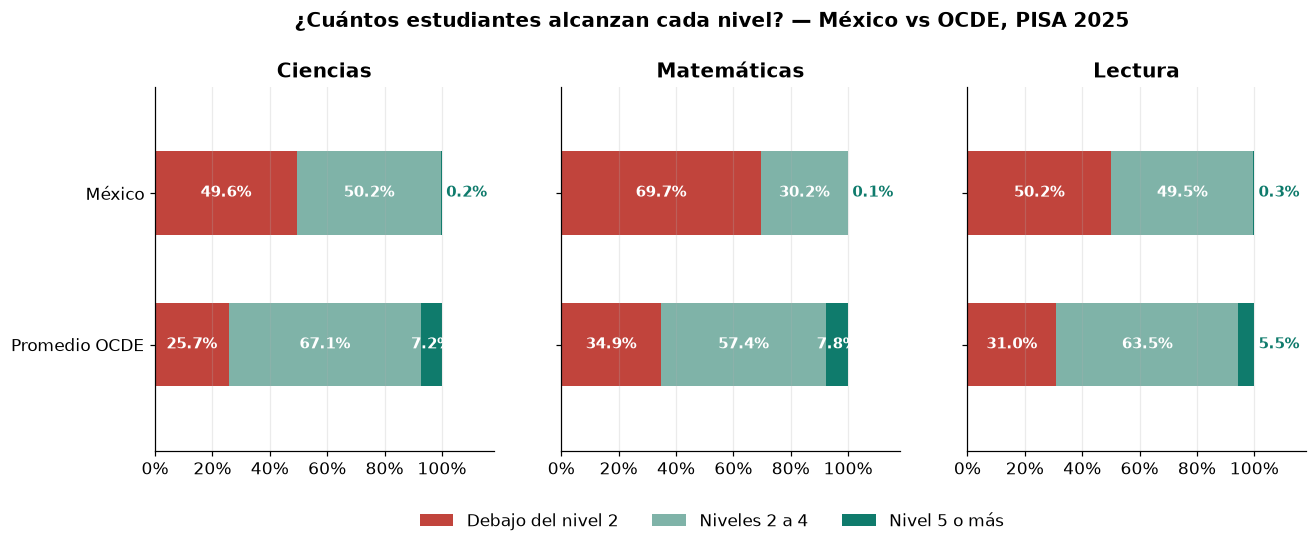

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3), sharex=True)

categorias = ["Debajo del nivel 2", "Niveles 2 a 4", "Nivel 5 o más"]
colores_nivel = [ROJO, "#7FB3A8", VERDE]
etiquetas_filas = [PAIS_NOMBRE, "Promedio OCDE"]
y = np.array([0.0, 1.0])

for k, (ax, materia) in enumerate(zip(axes, ["Ciencias", "Matemáticas", "Lectura"])):
    fila_mx = {cat: niveles_mx[materia][cat][0] for cat in categorias}
    datos_filas = [fila_mx, niveles_ocde[materia]]

    izquierda = np.zeros(2)
    for cat, color in zip(categorias, colores_nivel):
        vals = np.array([d[cat] for d in datos_filas])
        ax.barh(y, vals, left=izquierda, height=0.55, color=color)
        for yi, v, iz in zip(y, vals, izquierda):
            if v >= 7:
                ax.text(iz + v/2, yi, f"{v:.1f}%", ha="center", va="center",
                        color="white", fontweight="bold", fontsize=9.5)
        izquierda += vals

    for yi, fila in zip(y, datos_filas):
        v = fila["Nivel 5 o más"]
        if v < 7:
            ax.text(101.5, yi, f"{v:.1f}%", va="center", ha="left",
                    fontsize=9.5, color=VERDE, fontweight="bold")

    ax.set_title(materia)
    ax.set_yticks(y, etiquetas_filas if k == 0 else ["", ""])
    ax.set_xlim(0, 118)
    ax.set_ylim(1.7, -0.7)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis="y", visible=False)

fig.suptitle(f"¿Cuántos estudiantes alcanzan cada nivel? — {PAIS_NOMBRE} vs OCDE, PISA 2025",
             fontsize=13, fontweight="bold", y=1.04)
fig.legend(handles=[Patch(facecolor=c, label=t)
                    for t, c in zip(categorias, colores_nivel)],
           frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.09), ncol=3)

guardar(fig, "03_niveles_desempeno")
plt.show()

**Cómo leerla:** la barra roja es la parte preocupante. Pero fíjate en el otro
extremo, el verde: en la OCDE ~7% son de alto desempeño, en México ronda 0.2%. Esa es
la diferencia más brutal de la gráfica — no es que México tenga menos, es que
prácticamente no tiene.

Los márgenes de la tabla de arriba son chicos (±1 a ±2 puntos porcentuales), así que
todas estas brechas están muy lejos de ser azar.

---
# Gráfica 4 — ¿Importa más ser rico o pobre que ser listo?

PISA construye un índice llamado `ESCS` que resume tres cosas de cada estudiante:
educación de los padres, ocupación de los padres, y bienes en el hogar (libros, cuarto
propio, internet). Es un número donde **0 es el promedio internacional**.

Vamos a partir a los estudiantes mexicanos en **4 grupos del mismo tamaño** según ese
índice y ver el puntaje promedio de cada uno, con su margen de error.

*(Nombres técnicos: el índice es **ESCS**; los 4 grupos son **cuartiles**; la pendiente
resultante es el **gradiente socioeconómico**)*

In [46]:
def percentil_ponderado(valores, pesos, q):
    v, w = pd.Series(valores), pd.Series(pesos)
    ok = v.notna() & w.notna() & (w > 0)
    v, w = v[ok].values, w[ok].values
    orden = np.argsort(v)
    v, w = v[orden], w[orden]
    acumulado = (np.cumsum(w) - 0.5 * w) / w.sum()
    return float(np.interp(q, acumulado, v))

cortes_escs = [percentil_ponderado(mx["ESCS"], mx["W_FSTUWT"], q) for q in (.25, .50, .75)]

mx["GRUPO_ESCS"] = pd.cut(
    mx["ESCS"], bins=[-np.inf] + cortes_escs + [np.inf],
    labels=["25% más\ndesfavorecido", "Segundo\ncuarto",
            "Tercer\ncuarto", "25% más\nfavorecido"],
)
print("Cortes del índice ESCS:", [round(c, 2) for c in cortes_escs])

Cortes del índice ESCS: [-1.83, -1.01, 0.01]


In [47]:
# Esto tarda ~20 segundos: son 12 estimaciones × 10 valores plausibles × 81 pesos
grupos_orden = list(mx["GRUPO_ESCS"].cat.categories)
est_escs, ee_escs = {}, {}

for materia_nom, dom in [("Ciencias", "SCIE"), ("Matemáticas", "MATH"), ("Lectura", "READ")]:
    est_escs[materia_nom], ee_escs[materia_nom] = {}, {}
    for g in grupos_orden:
        e, s = estimar(mx[mx["GRUPO_ESCS"] == g], dom)
        est_escs[materia_nom][g], ee_escs[materia_nom][g] = e, s

tabla_escs   = pd.DataFrame(est_escs).loc[grupos_orden]
errores_escs = pd.DataFrame(ee_escs).loc[grupos_orden]

brecha, ee_brecha, t_brecha, sig_brecha = estimar_diferencia(
    mx, mx["GRUPO_ESCS"] == grupos_orden[-1], mx["GRUPO_ESCS"] == grupos_orden[0], "SCIE"
)

print(tabla_escs.round(1).to_string())
print("\nBrecha en ciencias (más favorecido − más desfavorecido):")
print(f"  {brecha:.1f} puntos, EE = {ee_brecha:.1f}, t = {t_brecha:.1f}")
print(f"  {'SIGNIFICATIVA' if sig_brecha else 'no significativa'} "
      f"→ equivale a ~{brecha/20:.1f} años de aprendizaje")

                        Ciencias  Matemáticas  Lectura
25% más\ndesfavorecido     383.0        362.7    376.4
Segundo\ncuarto            406.9        381.9    401.2
Tercer\ncuarto             420.0        392.1    414.4
25% más\nfavorecido        450.9        419.8    446.9

Brecha en ciencias (más favorecido − más desfavorecido):
  67.9 puntos, EE = 4.1, t = 16.6
  SIGNIFICATIVA → equivale a ~3.4 años de aprendizaje


Guardada: figuras/04_nivel_socioeconomico.png


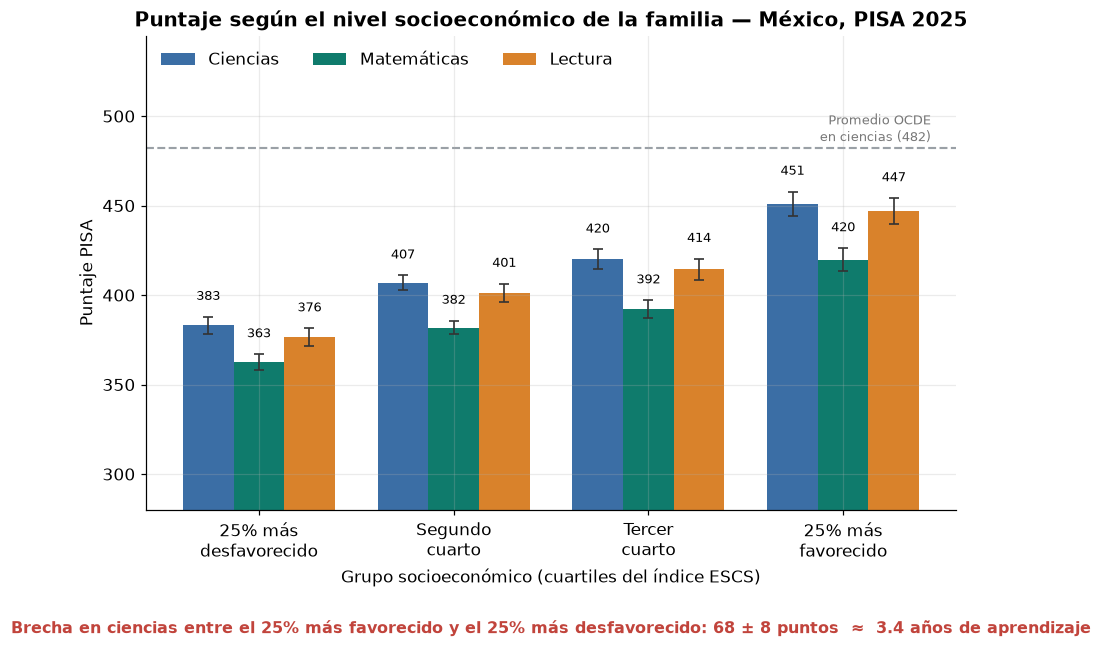

In [48]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))

x, ancho = np.arange(len(grupos_orden)), 0.26
for k, (materia, color) in enumerate(zip(
        ["Ciencias", "Matemáticas", "Lectura"], [AZUL, VERDE, NARANJA])):
    vals = tabla_escs[materia].values
    errs = 1.96 * errores_escs[materia].values          # margen al 95%
    b = ax.bar(x + (k - 1) * ancho, vals, ancho, label=materia, color=color,
               yerr=errs, capsize=3,
               error_kw=dict(ecolor="#333333", lw=1.1, capthick=1.1))
    ax.bar_label(b, labels=[f"{v:.0f}" for v in vals], padding=9, fontsize=8.5)

ax.axhline(482, color=GRIS, linestyle="--", linewidth=1.4, zorder=0)
ax.text(3.45, 486, "Promedio OCDE\nen ciencias (482)", fontsize=8.5,
        color="#777777", ha="right")

ax.text(0.5, -0.26,
        f"Brecha en ciencias entre el 25% más favorecido y el 25% más desfavorecido: "
        f"{brecha:.0f} ± {1.96*ee_brecha:.0f} puntos  ≈  {brecha/20:.1f} años de aprendizaje",
        transform=ax.transAxes, ha="center", color=ROJO, fontweight="bold", fontsize=10.5)

ax.set_title(f"Puntaje según el nivel socioeconómico de la familia — {PAIS_NOMBRE}, PISA 2025")
ax.set_ylabel("Puntaje PISA")
ax.set_xlabel("Grupo socioeconómico (cuartiles del índice ESCS)")
ax.set_xticks(x, grupos_orden)
ax.set_ylim(280, 545)
ax.legend(frameon=False, ncol=3, loc="upper left")

guardar(fig, "04_nivel_socioeconomico")
plt.show()

**Cómo leerla:** las líneas verticales sobre cada barra son el margen de error.
Como son cortas comparadas con los escalones, la escalera es real, no ruido.

Un detalle: aun el 25% más favorecido de México queda por debajo del promedio OCDE. No
es solo un problema de pobreza — el sistema completo está abajo.

**Advertencia:** esto es **correlación, no causa**. Que los niños de familias con más
recursos saquen mejor puntaje no prueba que el dinero *cause* el aprendizaje; hay
muchas cosas correlacionadas a la vez (calidad de la escuela, tiempo de los padres,
alimentación). *(El error a evitar se llama confundir **correlación con causalidad**)*

---
# Gráfica 5 — ¿Las niñas y los niños rinden igual?

El patrón mundial: los niños salen mejor en matemáticas, las niñas mejor en lectura, y
en ciencias suelen empatar. ¿México sigue el mismo patrón?

Aquí el margen de error importa muchísimo, porque las brechas de género suelen ser
chicas y es fácil ver diferencias donde no las hay.

La variable es `ST004D01D`: **1 = niña, 2 = niño** (confirmado en `STU_CommonFiles.do`,
línea 31).

*(Nombre técnico: **brecha de género** / gender gap)*

In [49]:
# Ver si salió en la lista de "no encontré estas" al cargar
print(faltantes)

[]


In [50]:
candidatas = [c for c in meta.column_names if c.upper().startswith("ST004")]
print("Columnas relacionadas con sexo:")
for c in candidatas:
    print(" -", c)

Columnas relacionadas con sexo:
 - ST004D01T


In [51]:
es_niña = mx["ST004D01T"] == 1
es_niño = mx["ST004D01T"] == 2

print(f"Niñas: {es_niña.sum():,}   |   Niños: {es_niño.sum():,}\n")

filas = []
for materia_nom, dom in [("Ciencias", "SCIE"), ("Matemáticas", "MATH"), ("Lectura", "READ")]:
    e_niña, s_niña = estimar(mx[es_niña], dom)
    e_niño, s_niño = estimar(mx[es_niño], dom)
    dif, ee_dif, t, sig = estimar_diferencia(mx, es_niño, es_niña, dom)
    filas.append({
        "Materia": materia_nom,
        "Niñas": e_niña, "EE niñas": s_niña,
        "Niños": e_niño, "EE niños": s_niño,
        "Diferencia": dif, "EE dif": ee_dif, "t": t,
        "¿Significativa?": "sí" if sig else "no",
    })

tabla_genero = pd.DataFrame(filas).set_index("Materia")
tabla_genero["Brecha OCDE"] = pd.Series({"Ciencias": -1, "Matemáticas": 13, "Lectura": -30})

print(tabla_genero.round(1).to_string())
print("\n(t mayor a 1.96 en valor absoluto = la diferencia no es azar)")

Niñas: 4,137   |   Niños: 3,706

             Niñas  EE niñas  Niños  EE niños  Diferencia  EE dif    t ¿Significativa?  Brecha OCDE
Materia                                                                                            
Ciencias     407.4       2.1  420.2       2.4        12.8     1.9  6.6              sí           -1
Matemáticas  380.0       1.9  395.8       2.3        15.8     1.8  8.6              sí           13
Lectura      413.8       2.1  401.6       2.6       -12.3     2.1 -5.9              sí          -30

(t mayor a 1.96 en valor absoluto = la diferencia no es azar)


Guardada: figuras/05_brecha_genero.png


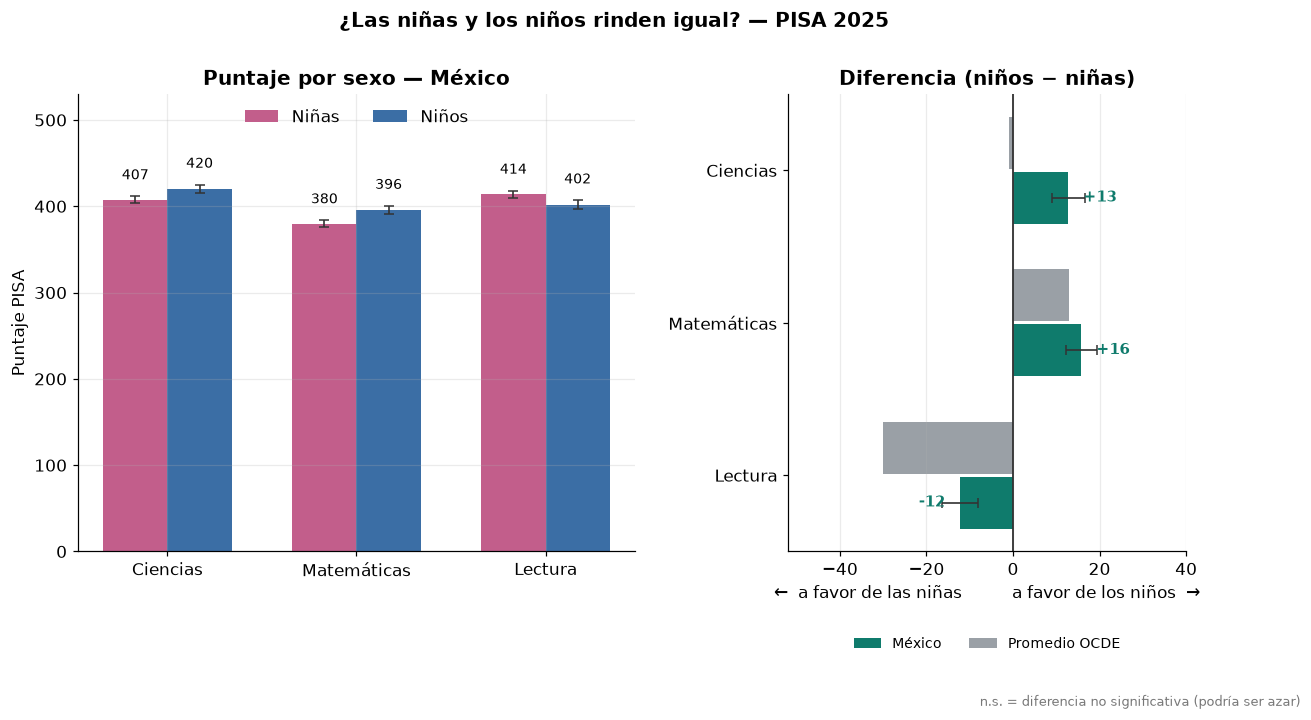

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4),
                               gridspec_kw={"width_ratios": [1.4, 1]})
materias = ["Ciencias", "Matemáticas", "Lectura"]

# --- Panel izquierdo: puntajes con su margen de error ---
x, ancho = np.arange(len(materias)), 0.34
b1 = ax1.bar(x - ancho/2, tabla_genero.loc[materias, "Niñas"], ancho, label="Niñas",
             color=ROSA, yerr=1.96*tabla_genero.loc[materias, "EE niñas"],
             capsize=3, error_kw=dict(ecolor="#333333", lw=1.1))
b2 = ax1.bar(x + ancho/2, tabla_genero.loc[materias, "Niños"], ancho, label="Niños",
             color=AZUL, yerr=1.96*tabla_genero.loc[materias, "EE niños"],
             capsize=3, error_kw=dict(ecolor="#333333", lw=1.1))
ax1.bar_label(b1, fmt="%.0f", padding=9, fontsize=9)
ax1.bar_label(b2, fmt="%.0f", padding=9, fontsize=9)

ax1.set_title(f"Puntaje por sexo — {PAIS_NOMBRE}")
ax1.set_ylabel("Puntaje PISA")
ax1.set_xticks(x, materias)
ax1.set_ylim(0, 530)
ax1.legend(frameon=False, loc="upper center", ncol=2)

# --- Panel derecho: la diferencia, con margen y marca de significancia ---
dif_mx   = tabla_genero.loc[materias, "Diferencia"].values
ee_mx    = 1.96 * tabla_genero.loc[materias, "EE dif"].values
dif_ocde = tabla_genero.loc[materias, "Brecha OCDE"].values
y = np.arange(len(materias), dtype=float)

ax2.barh(y + 0.18, dif_mx, 0.34, color=VERDE, label=PAIS_NOMBRE,
         xerr=ee_mx, capsize=3, error_kw=dict(ecolor="#333333", lw=1.1))
ax2.barh(y - 0.18, dif_ocde, 0.34, color=GRIS, label="Promedio OCDE")
ax2.axvline(0, color="#333333", linewidth=1.2)

for yi, v, sig in zip(y + 0.18, dif_mx, tabla_genero.loc[materias, "¿Significativa?"]):
    marca = "" if sig == "sí" else " n.s."
    ax2.text(v + (3.5 if v >= 0 else -3.5), yi, f"{v:+.0f}{marca}",
             va="center", ha="left" if v >= 0 else "right",
             fontsize=9.5, fontweight="bold", color=VERDE)

ax2.set_title("Diferencia (niños − niñas)")
ax2.set_xlabel("←  a favor de las niñas          a favor de los niños  →")
ax2.set_yticks(y, materias)
ax2.set_xlim(-52, 40)
ax2.set_ylim(len(materias) - 0.5, -0.5)
ax2.grid(axis="y", visible=False)
ax2.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16),
           ncol=2, fontsize=9)

fig.suptitle("¿Las niñas y los niños rinden igual? — PISA 2025",
             fontsize=13, fontweight="bold", y=1.02)
fig.subplots_adjust(wspace=0.32)
fig.text(0.98, -0.15, "n.s. = diferencia no significativa (podría ser azar)",
         ha="right", fontsize=8.5, color="#777777")

guardar(fig, "05_brecha_genero")
plt.show()

Guardada: figuras/08_genero_2018.png


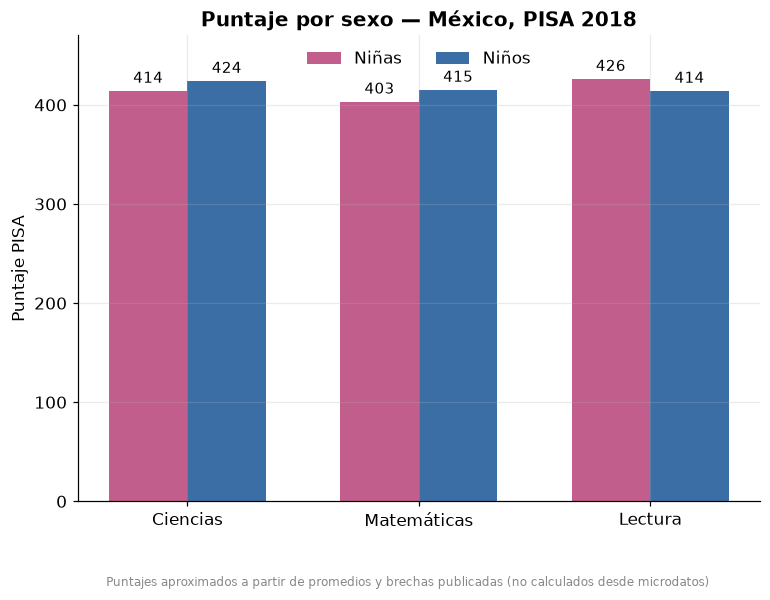

In [57]:
# ---------------------------------------------------------------------------
# Extra: mismo formato de gráfica, pero México 2018
# ---------------------------------------------------------------------------
# Puntajes reconstruidos a partir de cifras oficiales publicadas:
#   - Promedio nacional 2018 (OCDE / La Jornada, dic. 2019)
#   - Brecha de género publicada para cada materia
# Fórmula: niños = promedio + brecha/2 ; niñas = promedio − brecha/2
# (asume que ambos grupos pesan aprox. igual; es una aproximación, no el dato
#  exacto de microdatos como sí tenemos para 2025)

datos_2018 = pd.DataFrame({
    "Niñas": {"Ciencias": 414, "Matemáticas": 403, "Lectura": 426},
    "Niños": {"Ciencias": 424, "Matemáticas": 415, "Lectura": 414},
})
materias = ["Ciencias", "Matemáticas", "Lectura"]

fig, ax = plt.subplots(figsize=(8, 5.5))
x, ancho = np.arange(len(materias)), 0.34

b1 = ax.bar(x - ancho/2, datos_2018.loc[materias, "Niñas"], ancho,
            label="Niñas", color=ROSA)
b2 = ax.bar(x + ancho/2, datos_2018.loc[materias, "Niños"], ancho,
            label="Niños", color=AZUL)
ax.bar_label(b1, fmt="%.0f", padding=3, fontsize=10)
ax.bar_label(b2, fmt="%.0f", padding=3, fontsize=10)

ax.set_title("Puntaje por sexo — México, PISA 2018")
ax.set_ylabel("Puntaje PISA")
ax.set_xticks(x, materias)
ax.set_ylim(0, 470)
ax.legend(frameon=False, loc="upper center", ncol=2)

fig.text(0.5, -0.03,
         "Puntajes aproximados a partir de promedios y brechas publicadas "
         "(no calculados desde microdatos)",
         ha="center", fontsize=8, color="#888888")

guardar(fig, "08_genero_2018")
plt.show()

BRECHA DE GÉNERO EN JAPÓN

In [58]:
# ---------------------------------------------------------------------------
# EXTRA: brecha de género en Japón, PISA 2025
# ---------------------------------------------------------------------------
# Esta celda NO toca ninguna variable de México (usa nombres nuevos: jpn, no mx).
# Reutiliza el motor de estimación (estimar, estimar_diferencia) que ya
# definiste arriba, y el mismo archivo .sav que ya tienes cargado (ruta_stu).

# Paso 1: cargar solo las filas de Japón desde el archivo completo
trozos_jpn = []
lector_jpn = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sav, ruta_stu, chunksize=50_000, usecols=columnas_finales
)
for n, (trozo, _) in enumerate(lector_jpn, 1):
    trozo.columns = [c.upper() for c in trozo.columns]
    trozos_jpn.append(trozo[trozo["CNT"] == "JPN"])
    print(f"\rpedazo {n} procesado...", end="")

jpn = pd.concat(trozos_jpn, ignore_index=True)
jpn = jpn.dropna(subset=["W_FSTUWT"])
del trozos_jpn

print(f"\n\nJapón: {len(jpn):,} estudiantes en la muestra")
print(f"Representan a {jpn['W_FSTUWT'].sum():,.0f} jóvenes de 15 años del país")

pedazo 16 procesado...

Japón: 6,554 estudiantes en la muestra
Representan a 951,151 jóvenes de 15 años del país


In [59]:
# Paso 2: verificar contra las cifras oficiales publicadas (OCDE, 8-sep-2026)
oficial_jpn = {"MATH": 525, "READ": 503, "SCIE": 538}

print("Verificación Japón — PISA 2025")
print("-" * 55)
for dom, valor_oficial in oficial_jpn.items():
    est, ee = estimar(jpn, dom)
    ok = "✓" if abs(est - valor_oficial) < 2 else "✗"
    print(f"{ok} {nombres[dom]:<12} {ic95(est, ee)}   oficial: {valor_oficial}")

Verificación Japón — PISA 2025
-------------------------------------------------------
✓ Matemáticas  525.4 ± 8.2  (IC95: 517.1 a 533.6)   oficial: 525
✓ Lectura      502.7 ± 7.4  (IC95: 495.3 a 510.1)   oficial: 503
✓ Ciencias     537.6 ± 7.5  (IC95: 530.1 a 545.0)   oficial: 538


In [60]:
# Paso 3: brecha de género en Japón, con margen de error (mismo método que México)
es_niña_jpn = jpn["ST004D01T"] == 1
es_niño_jpn = jpn["ST004D01T"] == 2

print(f"Niñas: {es_niña_jpn.sum():,}   |   Niños: {es_niño_jpn.sum():,}\n")

filas_jpn = []
for materia_nom, dom in [("Ciencias", "SCIE"), ("Matemáticas", "MATH"), ("Lectura", "READ")]:
    e_niña, s_niña = estimar(jpn[es_niña_jpn], dom)
    e_niño, s_niño = estimar(jpn[es_niño_jpn], dom)
    dif, ee_dif, t, sig = estimar_diferencia(jpn, es_niño_jpn, es_niña_jpn, dom)
    filas_jpn.append({
        "Materia": materia_nom,
        "Niñas": e_niña, "EE niñas": s_niña,
        "Niños": e_niño, "EE niños": s_niño,
        "Diferencia": dif, "EE dif": ee_dif, "t": t,
        "¿Significativa?": "sí" if sig else "no",
    })

tabla_genero_jpn = pd.DataFrame(filas_jpn).set_index("Materia")
print(tabla_genero_jpn.round(1).to_string())

Niñas: 3,156   |   Niños: 3,398

             Niñas  EE niñas  Niños  EE niños  Diferencia  EE dif    t ¿Significativa?
Materia                                                                               
Ciencias     532.6       4.2  542.3       4.7         9.6     4.8  2.0              sí
Matemáticas  517.0       4.8  533.3       5.2        16.3     5.7  2.9              sí
Lectura      509.9       4.0  495.9       5.0       -14.0     4.8 -2.9              sí


Guardada: figuras/09_genero_japon_2025.png


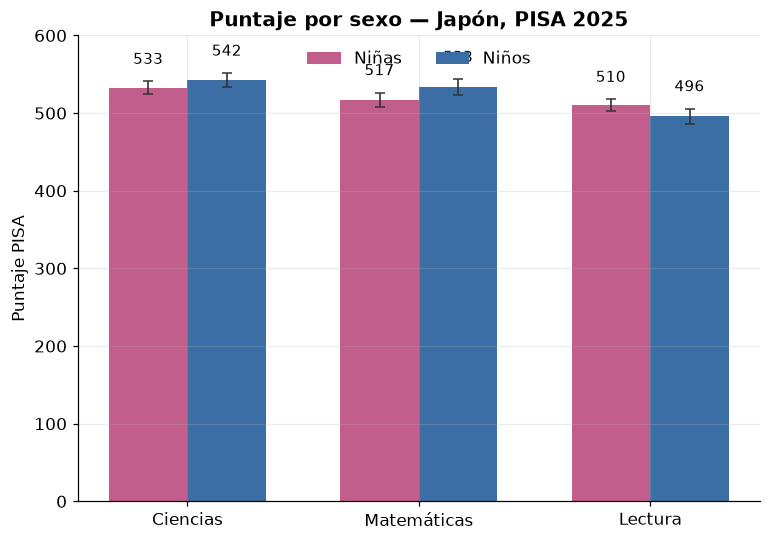

In [61]:
# Paso 4: la gráfica, mismo formato que la de México
materias = ["Ciencias", "Matemáticas", "Lectura"]

fig, ax = plt.subplots(figsize=(8, 5.5))
x, ancho = np.arange(len(materias)), 0.34

b1 = ax.bar(x - ancho/2, tabla_genero_jpn.loc[materias, "Niñas"], ancho,
            label="Niñas", color=ROSA,
            yerr=1.96*tabla_genero_jpn.loc[materias, "EE niñas"],
            capsize=3, error_kw=dict(ecolor="#333333", lw=1.1))
b2 = ax.bar(x + ancho/2, tabla_genero_jpn.loc[materias, "Niños"], ancho,
            label="Niños", color=AZUL,
            yerr=1.96*tabla_genero_jpn.loc[materias, "EE niños"],
            capsize=3, error_kw=dict(ecolor="#333333", lw=1.1))
ax.bar_label(b1, fmt="%.0f", padding=9, fontsize=10)
ax.bar_label(b2, fmt="%.0f", padding=9, fontsize=10)

ax.set_title("Puntaje por sexo — Japón, PISA 2025")
ax.set_ylabel("Puntaje PISA")
ax.set_xticks(x, materias)
ax.set_ylim(0, 600)
ax.legend(frameon=False, loc="upper center", ncol=2)

guardar(fig, "09_genero_japon_2025")
plt.show()

QUÉ PAÍS TIENE LA MENOR BRECHA DE GÉNERO??

In [62]:
# ---------------------------------------------------------------------------
# EXTRA: ¿qué país tiene la menor brecha de género?
# ---------------------------------------------------------------------------
# Carga TODOS los países del archivo (no solo México/Japón). Usa las mismas
# columnas que ya definiste en columnas_finales, así que no vuelve a pedirte
# nada nuevo. Tarda más porque son ~760,000 filas en vez de unos cuantos miles.

trozos_todos = []
lector_todos = pyreadstat.read_file_in_chunks(
    pyreadstat.read_sav, ruta_stu, chunksize=50_000, usecols=columnas_finales
)
for n, (trozo, _) in enumerate(lector_todos, 1):
    trozo.columns = [c.upper() for c in trozo.columns]
    trozos_todos.append(trozo)
    print(f"\rpedazo {n} procesado...", end="")

df_todos = pd.concat(trozos_todos, ignore_index=True)
df_todos = df_todos.dropna(subset=["W_FSTUWT"])
del trozos_todos

print(f"\n\nCargado: {len(df_todos):,} estudiantes de {df_todos['CNT'].nunique()} países/economías")

pedazo 16 procesado...

Cargado: 755,721 estudiantes de 90 países/economías


In [63]:
# Para cada país, calcula la diferencia niños-niñas (con margen de error)
# en ciencias, matemáticas y lectura. Tarda 2-4 min porque son ~90 países.

MIN_ESTUDIANTES_POR_GRUPO = 200  # países con menos que esto se excluyen (poco fiable)

resultados_genero = []

for i, pais in enumerate(sorted(df_todos["CNT"].unique()), 1):
    sub = df_todos[df_todos["CNT"] == pais]
    es_niña_p = sub["ST004D01T"] == 1
    es_niño_p = sub["ST004D01T"] == 2

    if es_niña_p.sum() < MIN_ESTUDIANTES_POR_GRUPO or es_niño_p.sum() < MIN_ESTUDIANTES_POR_GRUPO:
        continue

    fila = {"pais": pais}
    for materia_nom, dom in [("Ciencias", "SCIE"), ("Matemáticas", "MATH"), ("Lectura", "READ")]:
        dif, ee_dif, t, sig = estimar_diferencia(sub, es_niño_p, es_niña_p, dom)
        fila[f"dif_{materia_nom}"] = dif
        fila[f"sig_{materia_nom}"] = sig

    resultados_genero.append(fila)
    print(f"\r{i}/{df_todos['CNT'].nunique()} países procesados...", end="")

tabla_brechas = pd.DataFrame(resultados_genero).set_index("pais")

# Una columna resumen: qué tan lejos de cero está, en promedio, en las 3 materias
tabla_brechas["brecha_promedio_abs"] = tabla_brechas[
    ["dif_Ciencias", "dif_Matemáticas", "dif_Lectura"]
].abs().mean(axis=1)

# Cuántas de las 3 diferencias son estadísticamente significativas
tabla_brechas["num_significativas"] = tabla_brechas[
    ["sig_Ciencias", "sig_Matemáticas", "sig_Lectura"]
].sum(axis=1)

print(f"\n\n{len(tabla_brechas)} países con muestra suficiente")

90/90 países procesados...

76 países con muestra suficiente


In [64]:
# Ordenar por la brecha promedio (en valor absoluto) de menor a mayor
ranking = tabla_brechas.sort_values("brecha_promedio_abs")

print("TOP 10 países con MENOR brecha de género promedio (2025)")
print("=" * 70)
cols_mostrar = ["dif_Ciencias", "dif_Matemáticas", "dif_Lectura",
                "brecha_promedio_abs", "num_significativas"]
print(ranking[cols_mostrar].head(10).round(1).to_string())

print("\n" + "=" * 70)
ganador = ranking.index[0]
fila_g = ranking.iloc[0]
print(f"\nEl país con la brecha de género más chica en general es: {ganador}")
print(f"  Ciencias:    {fila_g['dif_Ciencias']:+.1f} puntos "
      f"({'significativa' if fila_g['sig_Ciencias'] else 'NO significativa'})")
print(f"  Matemáticas: {fila_g['dif_Matemáticas']:+.1f} puntos "
      f"({'significativa' if fila_g['sig_Matemáticas'] else 'NO significativa'})")
print(f"  Lectura:     {fila_g['dif_Lectura']:+.1f} puntos "
      f"({'significativa' if fila_g['sig_Lectura'] else 'NO significativa'})")

# También: países donde NINGUNA de las 3 diferencias es significativa
# (el candidato más fuerte a "sin brecha real")
sin_brecha_real = ranking[ranking["num_significativas"] == 0]
print(f"\nPaíses donde NINGUNA brecha es estadísticamente significativa "
      f"(las 3 podrían ser puro azar): {len(sin_brecha_real)}")
if len(sin_brecha_real) > 0:
    print(sin_brecha_real[cols_mostrar].round(1).to_string())

TOP 10 países con MENOR brecha de género promedio (2025)
      dif_Ciencias  dif_Matemáticas  dif_Lectura  brecha_promedio_abs  num_significativas
pais                                                                                     
LBN            4.6              6.8         -9.6                  7.0                   1
MAR           -2.7             -1.9        -16.6                  7.0                   1
QTJ            3.8             14.9         -8.3                  9.0                   2
GTM            9.2              9.3         -9.2                  9.3                   3
UZB           -9.4              NaN          NaN                  9.4                   1
MYS           -1.1              6.0        -21.7                  9.6                   2
BRN           -0.7              3.3        -24.9                  9.6                   1
MUS           -5.5              4.1        -20.2                  9.9                   1
BRA            1.5              7.4        

**Cómo leerla:** las barras marcadas `n.s.` son diferencias que **no puedes
afirmar**: caen dentro del margen de error, así que podrían ser puro azar del muestreo.

Esto es exactamente lo que evita que publiques una conclusión falsa. Sin los márgenes,
una diferencia de 4 puntos parece un hallazgo; con ellos, ves que no lo es.

---
# Gráfica 6 — ¿Los que usan IA sacan mejores o peores notas?

PISA 2025 preguntó por primera vez sobre uso de inteligencia artificial
(`ST438Q01DA` a `ST438Q04DA`, escala de 1 = nunca a 5 = todos los días). Siguiendo el
criterio de la OCDE, **"uso frecuente" = respondió 4 o 5** en al menos una.

**El truco metodológico:** comparar directo sería tramposo. Los estudiantes con más
recursos tienen más acceso a IA *y* mejores puntajes por otras razones. Si comparas sin
más, no sabes si mides el efecto de la IA o el de tener dinero.

Por eso el panel derecho repite la comparación **dentro de cada grupo socioeconómico**:
compara ricos con ricos y pobres con pobres.

*(Nombres técnicos: la variable que ensucia la comparación es una **variable de
confusión** / confounder; separar por grupos para neutralizarla es **estratificar**)*

In [53]:
cols_ia = [c for c in (f"ST438Q0{i}DA" for i in range(1, 5)) if c in mx.columns]

if not cols_ia:
    raise KeyError("No están las columnas de uso de IA en este archivo. "
                   "Revisa el diccionario de variables (codebook) de la OCDE.")

print("Columnas de IA encontradas:", cols_ia)

usa = (mx[cols_ia] >= 4).any(axis=1)
sin_respuesta = mx[cols_ia].isna().all(axis=1)
mx["USA_IA"] = np.where(sin_respuesta, np.nan, usa.astype(float))

w = mx["W_FSTUWT"]
pct_ia = 100 * w[mx["USA_IA"] == 1].sum() / w[mx["USA_IA"].notna()].sum()
print(f"\n{pct_ia:.1f}% de los estudiantes en {PAIS_NOMBRE} usa IA al menos "
      f"una vez por semana.")

Columnas de IA encontradas: ['ST438Q01DA', 'ST438Q02DA', 'ST438Q03DA', 'ST438Q04DA']

58.7% de los estudiantes en México usa IA al menos una vez por semana.


In [54]:
con_ia = mx["USA_IA"] == 1
sin_ia = mx["USA_IA"] == 0

# --- Comparación simple ---
filas = []
for materia_nom, dom in [("Ciencias", "SCIE"), ("Matemáticas", "MATH"), ("Lectura", "READ")]:
    e_con, s_con = estimar(mx[con_ia], dom)
    e_sin, s_sin = estimar(mx[sin_ia], dom)
    dif, ee_dif, t, sig = estimar_diferencia(mx, con_ia, sin_ia, dom)
    filas.append({"Materia": materia_nom,
                  "Usa IA seguido": e_con, "EE con": s_con,
                  "Casi no usa IA": e_sin, "EE sin": s_sin,
                  "Diferencia": dif, "EE dif": ee_dif, "t": t,
                  "¿Significativa?": "sí" if sig else "no"})
simple = pd.DataFrame(filas).set_index("Materia")

# --- La misma comparación dentro de cada grupo socioeconómico (ciencias) ---
filas = []
for g in grupos_orden:
    en_grupo = mx["GRUPO_ESCS"] == g
    e_con, s_con = estimar(mx[en_grupo & con_ia], "SCIE")
    e_sin, s_sin = estimar(mx[en_grupo & sin_ia], "SCIE")
    dif, ee_dif, t, sig = estimar_diferencia(mx, en_grupo & con_ia, en_grupo & sin_ia, "SCIE")
    filas.append({"Grupo": str(g).replace("\n", " "),
                  "Usa IA seguido": e_con, "EE con": s_con,
                  "Casi no usa IA": e_sin, "EE sin": s_sin,
                  "Diferencia": dif, "EE dif": ee_dif, "t": t,
                  "¿Significativa?": "sí" if sig else "no"})
por_grupo = pd.DataFrame(filas).set_index("Grupo")

print("Comparación directa (puede engañar):")
print(simple.round(1).to_string())
print("\nDentro de cada grupo socioeconómico — solo ciencias:")
print(por_grupo.round(1).to_string())

Comparación directa (puede engañar):
             Usa IA seguido  EE con  Casi no usa IA  EE sin  Diferencia  EE dif    t ¿Significativa?
Materia                                                                                             
Ciencias              424.1     2.2           406.8     2.4        17.4     2.1  8.1              sí
Matemáticas           397.3     2.0           380.9     2.1        16.4     1.9  8.7              sí
Lectura               419.9     2.3           399.5     2.7        20.4     2.4  8.5              sí

Dentro de cada grupo socioeconómico — solo ciencias:
                       Usa IA seguido  EE con  Casi no usa IA  EE sin  Diferencia  EE dif    t ¿Significativa?
Grupo                                                                                                         
25% más desfavorecido           391.4     3.1           382.2     3.4         9.2     4.0  2.3              sí
Segundo cuarto                  415.3     2.4           400.2     3.1  

Guardada: figuras/06_uso_de_ia.png


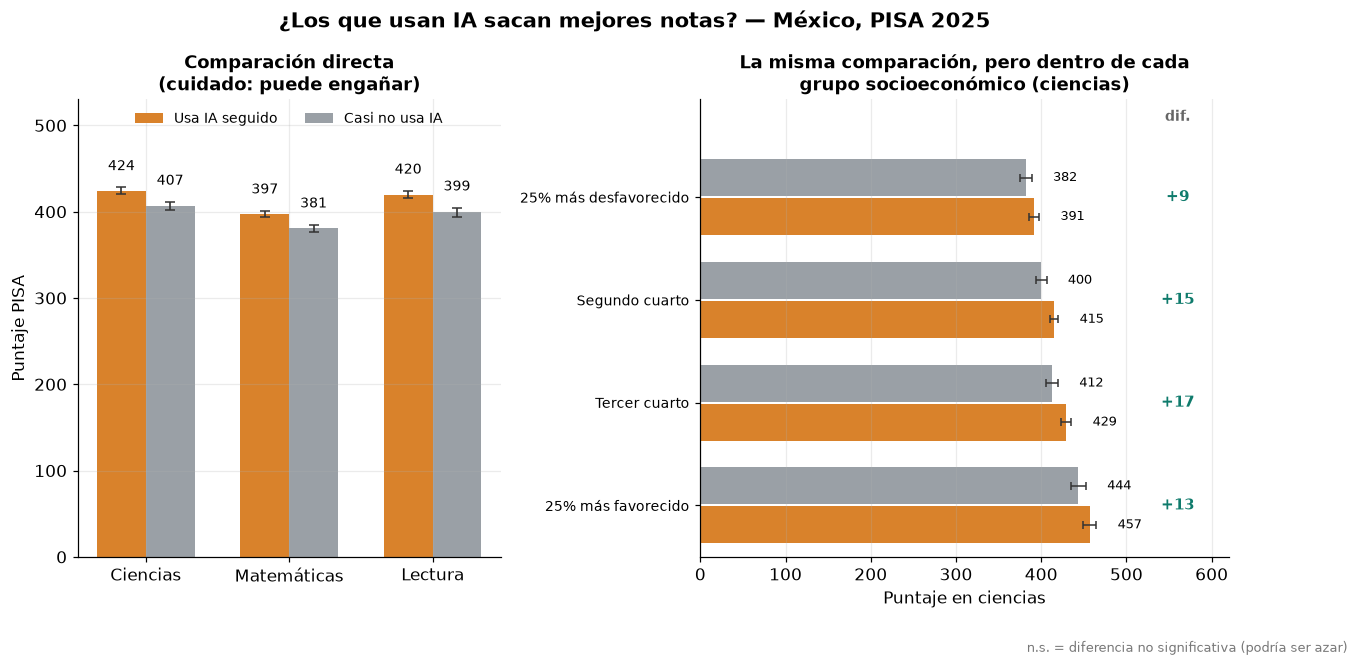

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 5.4),
                               gridspec_kw={"width_ratios": [1, 1.25]})
materias = ["Ciencias", "Matemáticas", "Lectura"]

# --- Panel 1: comparación directa ---
x, ancho = np.arange(len(materias)), 0.34
b1 = ax1.bar(x - ancho/2, simple.loc[materias, "Usa IA seguido"], ancho,
             label="Usa IA seguido", color=NARANJA,
             yerr=1.96*simple.loc[materias, "EE con"], capsize=3,
             error_kw=dict(ecolor="#333333", lw=1.1))
b2 = ax1.bar(x + ancho/2, simple.loc[materias, "Casi no usa IA"], ancho,
             label="Casi no usa IA", color=GRIS,
             yerr=1.96*simple.loc[materias, "EE sin"], capsize=3,
             error_kw=dict(ecolor="#333333", lw=1.1))
ax1.bar_label(b1, fmt="%.0f", padding=9, fontsize=9)
ax1.bar_label(b2, fmt="%.0f", padding=9, fontsize=9)

ax1.set_title("Comparación directa\n(cuidado: puede engañar)", fontsize=12)
ax1.set_ylabel("Puntaje PISA")
ax1.set_xticks(x, materias)
ax1.set_ylim(0, 530)
ax1.legend(frameon=False, loc="upper center", ncol=2, fontsize=9)

# --- Panel 2: dentro de cada grupo socioeconómico ---
grupos_txt = list(por_grupo.index)
y = np.arange(len(grupos_txt), dtype=float)
X_DIF = 560

b3 = ax2.barh(y + 0.19, por_grupo["Usa IA seguido"], 0.36, color=NARANJA,
              xerr=1.96*por_grupo["EE con"], capsize=2.5,
              error_kw=dict(ecolor="#333333", lw=1))
b4 = ax2.barh(y - 0.19, por_grupo["Casi no usa IA"], 0.36, color=GRIS,
              xerr=1.96*por_grupo["EE sin"], capsize=2.5,
              error_kw=dict(ecolor="#333333", lw=1))
ax2.bar_label(b3, fmt="%.0f", padding=14, fontsize=8.5)
ax2.bar_label(b4, fmt="%.0f", padding=14, fontsize=8.5)

ax2.text(X_DIF, -0.78, "dif.", va="center", ha="center",
         fontsize=9, color="#666666", fontweight="bold")
for yi, dif, sig in zip(y, por_grupo["Diferencia"], por_grupo["¿Significativa?"]):
    color = (VERDE if dif > 0 else ROJO) if sig == "sí" else "#999999"
    texto = f"{dif:+.0f}" + ("" if sig == "sí" else " n.s.")
    ax2.text(X_DIF, yi, texto, va="center", ha="center",
             fontsize=10, fontweight="bold", color=color)

ax2.set_title("La misma comparación, pero dentro de cada\ngrupo socioeconómico (ciencias)",
              fontsize=12)
ax2.set_xlabel("Puntaje en ciencias")
ax2.set_yticks(y, grupos_txt, fontsize=9)
ax2.set_xlim(0, 620)
ax2.set_ylim(len(grupos_txt) - 0.5, -0.95)
ax2.grid(axis="y", visible=False)

fig.suptitle(f"¿Los que usan IA sacan mejores notas? — {PAIS_NOMBRE}, PISA 2025",
             fontsize=13.5, fontweight="bold", y=1.03)
fig.subplots_adjust(wspace=0.42)
fig.text(0.98, -0.05, "n.s. = diferencia no significativa (podría ser azar)",
         ha="right", fontsize=8.5, color="#777777")

guardar(fig, "06_uso_de_ia")
plt.show()

**Cómo leerla:** compara los dos paneles.

Si en el izquierdo la diferencia se ve grande pero en el derecho se encoge o aparece
como `n.s.` dentro de cada grupo, entonces **lo que medías era nivel socioeconómico
disfrazado de "efecto de la IA"**. Ese es justo el error que produce titulares falsos.

Si la diferencia se mantiene y sigue siendo significativa en todos los grupos, es una
señal más interesante — aunque **sigue sin probar causa**: podría ser que los
estudiantes más aplicados usen más IA, y no al revés.

La OCDE reportó a nivel internacional que la relación **no es lineal**: el uso moderado
se asocia a mejor desempeño que el uso nulo *y* que el uso muy intenso.

---
# Listo

Las 6 gráficas están en `figuras/` en PNG a 200 dpi.

## Qué cambió respecto a la versión anterior

Ahora todo se calcula con el método oficial de la OCDE:

- **Promedios** — ponderados y promediados sobre los 10 valores plausibles.
- **Márgenes de error** — BRR con corrección de Fay sobre los 80 pesos replicados,
  combinado con la varianza de imputación por las reglas de Rubin.
- **Diferencias entre grupos** — recalculadas dentro de cada réplica, lo que captura
  que ambos grupos vienen de la misma muestra.
- **Marca `n.s.`** en las gráficas donde una diferencia cae dentro del margen y por
  tanto no se puede afirmar.

Con esto sí puedes escribir "la diferencia es estadísticamente significativa" y
sostenerlo.

## Si quieres seguir

- Cambia `PAIS = "MEX"` por `"CHL"`, `"BRA"`, `"URY"` o `"COL"` y corre todo otra vez
  (ya están cargados en `df`).
- Compara México contra otro país con `estimar_diferencia` sobre `df`, usando máscaras
  de `CNT`.
- Cruza con el archivo de escuelas (`CNTSCHID`) para el tema de la prohibición de
  celulares.

## Dos límites que siguen ahí

**Los grados de libertad.** Uso 1.96 (aproximación normal) para el 95%. La OCDE usa una
t con grados de libertad ajustados, lo que da márgenes ligeramente más anchos en grupos
chicos. La diferencia es menor pero existe.

**Comparaciones múltiples.** Si haces 20 comparaciones, ~1 va a salir "significativa"
por pura casualidad. Si vas a probar muchas hipótesis a la vez, hay que ajustar
(Bonferroni, Benjamini-Hochberg). Para las 6 gráficas de aquí no hace falta.

Todo esto está en el *PISA Data Analysis Manual*, en la misma página de descarga.
